In [14]:
import copy
import os
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyref.fitting as fit
from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpecFromSubplotSpec
from matplotlib.patches import Patch
from refnx.analysis import Transform
import scienceplots
from scipy.stats import gaussian_kde
from uncertainties import nominal_value, std_dev, ufloat
from uncertainties import umath
from uncertainties import unumpy as unp

UMATH: Any = umath
UNP: Any = unp

CPU_COUNT = os.cpu_count()

plt.style.use(["science"])
# Set RCParams
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 8
# plt.rcParams["figure.dpi"] = 300
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"

# Load the Data Files


Dataset loaded from reflectivity_data.parquet


(<Axes: ylabel='$R$'>, <Axes: xlabel='$q (\\AA^{-1})$'>)

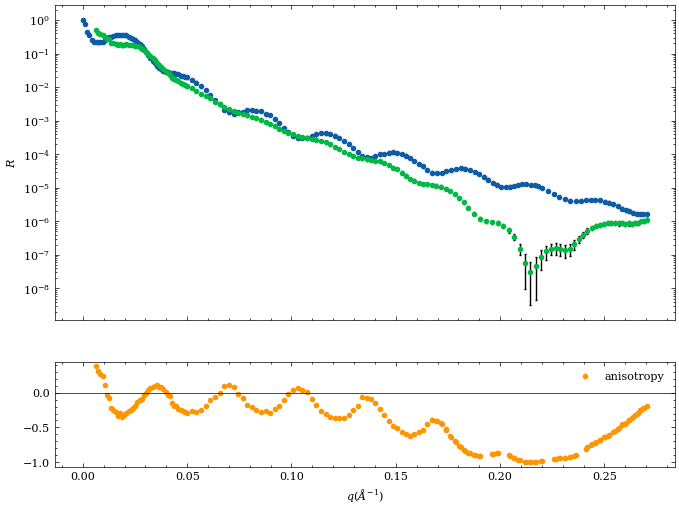

In [15]:
def load_reflectivity_dataset(filename):
    """
    Load reflectivity dataset from a parquet file.

    Parameters
    ----------
    filename : str
        Input filename (should be a .parquet file)

    Returns
    -------
    dict
        Dictionary containing XrayReflectDataset objects with energy keys
    """
    # Load the DataFrame
    df_load = pl.read_parquet(filename)

    # Reconstruct the data dictionary
    data_reconstructed = {}

    # Group by energy
    for group_key, group_data in df_load.group_by("energy"):
        energy_val = group_key[0]  # Extract energy value from the group key tuple

        # Extract arrays
        Q = group_data["Q"].to_numpy()
        R = group_data["R"].to_numpy()
        dR = group_data["dR"].to_numpy()

        # Create XrayReflectDataset
        dataset = fit.XrayReflectDataset(data=(Q, R, dR))
        data_reconstructed[str(energy_val)] = dataset

    print(f"Dataset loaded from {filename}")
    return data_reconstructed


# # Save the dataset to a parquet file
# save_reflectivity_dataset(data, "reflectivity_data.parquet")
# # Load the dataset back from the parquet file
loaded_data = load_reflectivity_dataset("reflectivity_data.parquet")
loaded_data["283.7"].plot(label="283.7 eV data")

In [16]:
import pickle

with open("../fitting/fitting_results_fixed.pkl", "rb") as f:
    dft_constrained = pickle.load(f)

In [17]:
ooc = pd.read_csv("../fitting/optical_constants.csv")
# Zoom from 270 to 300 eV
ooc = ooc[(ooc["energy"] > 270) & (ooc["energy"] < 300)]

def parameter_to_ufloat(param, *, default_sigma=0.0):
    nominal = getattr(param, "value", float(param))
    sigma = getattr(param, "stderr", None)
    if sigma is None:
        sigma = default_sigma
    return ufloat(nominal, sigma)

def combine_sigmas(*sigmas):
    valid = [sigma for sigma in sigmas if sigma is not None]
    if not valid:
        return None
    return np.sqrt(np.sum(np.square(valid)))

def make_ufloat(nominal, sigma, *, fallback_scale=2.0):
    if sigma is None:
        sigma = abs(nominal) * fallback_scale
    return ufloat(nominal, sigma)

def series_to_uarray(frame, value_column, error_column=None):
    values = frame[value_column].to_numpy()
    if error_column is not None and error_column in frame:
        errors = frame[error_column].fillna(0.0).to_numpy()
    else:
        errors = np.zeros_like(values, dtype=float)
    return unp.uarray(values, errors)

def u_cos(value):
    return getattr(UNP, "cos")(value)

def u_sin(value):
    return getattr(UNP, "sin")(value)

#  extract orientation from dft_constrained system
dft_objectives = {obj.model.energy: obj for obj in dft_constrained.objectives}
o = dft_objectives[283.7]

rotations = {
    "contamination": parameter_to_ufloat(o.model.structure[1].sld.rotation),
    "bulk": parameter_to_ufloat(o.model.structure[2].sld.rotation),
    "interface": parameter_to_ufloat(o.model.structure[3].sld.rotation),
}

density = {
    "contamination": parameter_to_ufloat(o.model.structure[1].sld.density),
    "bulk": parameter_to_ufloat(o.model.structure[2].sld.density),
    "interface": parameter_to_ufloat(o.model.structure[3].sld.density),
}

# Extract the imaginary components and their errors from the exp_constrained dataset
def optical_constants(model):
    oc = {}
    names = ["contamination", "bulk", "interface"]
    for i, s in enumerate(model.structure):

        if isinstance(s.sld, fit.UniTensorSLD):
            print(s)
            break
        if i in [0, 4, 5]:
            continue

        n_ixx = make_ufloat(
            s.sld.ixx.value,
            combine_sigmas(s.sld.dichroism.stderr, s.sld.beta.stderr),
        )
        n_izz = make_ufloat(
            s.sld.izz.value,
            combine_sigmas(s.sld.dichroism.stderr, s.sld.beta.stderr),
        )
        n_xx = make_ufloat(
            s.sld.xx.value,
            combine_sigmas(s.sld.birefringence.stderr, s.sld.delta.stderr),
        )
        n_zz = make_ufloat(
            s.sld.zz.value,
            combine_sigmas(s.sld.birefringence.stderr, s.sld.delta.stderr),
        )

        if nominal_value(n_ixx) < 0 or nominal_value(n_izz) < 0:
            print(f"Negative n_ixx or n_izz for {s.sld.name} at {s.sld.energy} eV")

        oc[names[i - 1]] = {
            "n_ixx": nominal_value(n_ixx),
            "n_ixx_err": std_dev(n_ixx),
            "n_izz": nominal_value(n_izz),
            "n_izz_err": std_dev(n_izz),
            "n_xx": nominal_value(n_xx),
            "n_xx_err": std_dev(n_xx),
            "n_zz": nominal_value(n_zz),
            "n_zz_err": std_dev(n_zz),
        }
    return oc

def extract_optical_constants(objectives):
    contamination = []
    bulk = []
    interface = []
    for objective in objectives:
        if objective.model.energy == 250.0:
            continue
        oc = optical_constants(objective.model)
        contamination.append({"energy": objective.model.energy, **oc["contamination"]})
        bulk.append({"energy": objective.model.energy, **oc["bulk"]})
        interface.append({"energy": objective.model.energy, **oc["interface"]})
    contamination = pd.DataFrame(contamination)
    bulk = pd.DataFrame(bulk)
    interface = pd.DataFrame(interface)
    return contamination, bulk, interface

def optical_tensor(ooc_frame, rotation, density):
    """Calculate the optical tensor for a given rotation and density."""
    c = u_cos(rotation) ** 2
    s = u_sin(rotation) ** 2

    n_xx = series_to_uarray(ooc_frame, "n_xx", "n_xx_err")
    n_zz = series_to_uarray(ooc_frame, "n_zz", "n_zz_err")
    n_ixx = series_to_uarray(ooc_frame, "n_ixx", "n_ixx_err")
    n_izz = series_to_uarray(ooc_frame, "n_izz", "n_izz_err")

    tensors = {
        "n_o": ((n_xx * (c + 1)) + n_zz * s) / 2,
        "n_e": (n_xx * s) + (n_zz * c),
        "n_io": ((n_ixx * (c + 1)) + n_izz * s) / 2,
        "n_ie": (n_ixx * s) + (n_izz * c),
    }

    scaled = {key: value * density for key, value in tensors.items()}

    def to_dataframe(label):
        uarr = scaled[label]
        return pd.DataFrame(
            {
                "energy": ooc_frame["energy"].to_numpy(),
                label: unp.nominal_values(uarr),
                f"{label}_err": unp.std_devs(uarr),
            }
        )

    return tuple(to_dataframe(label) for label in ["n_o", "n_e", "n_io", "n_ie"])

c_o, c_e, c_io, c_ie = optical_tensor(ooc, rotations["contamination"], density["contamination"])
b_o, b_e, b_io, b_ie = optical_tensor(ooc, rotations["bulk"], density["bulk"])
i_o, i_e, i_io, i_ie = optical_tensor(ooc, rotations["interface"], density["interface"])


# Load Optical Constants for Constraints and OOC instantiation


In [18]:
import pickle
ZNPC = "C32H16N8Zn"

def contamination(energy, thick=4.4, rough=2, density=1.0):
    """Contamination."""
    name = f"Contamination_{energy}"
    slab = fit.MaterialSLD(
        ZNPC, density=density, energy=energy, name=name
    )(thick, rough)
    slab.sld.density.setp(vary=True, bounds=(1, 1.8))

    slab.thick.setp(vary=True, bounds=(0, 12))
    slab.rough.setp(vary=True, bounds=(0, 5))
    return slab


def surface(energy, thick=3.3, rough=1, density=1.0):
    """Surface."""
    name = f"Surface_{energy}"
    slab = fit.MaterialSLD(
        ZNPC, density=density, energy=energy, name=name
    )(thick, rough)
    slab.sld.density.setp(vary=True, bounds=(1, 1.8))

    slab.thick.setp(vary=True, bounds=(0, 12))
    slab.rough.setp(vary=True, bounds=(0, 5))
    return slab


def znpc(energy, thick=191, rough=8.8, density=1.61):
    """ZnPc."""
    name = f"ZnPc_{energy}"
    slab = fit.MaterialSLD(
        ZNPC, density=density, energy=energy, name=name
    )(thick, rough)
    slab.sld.density.setp(vary=True, bounds=(1.2, 1.8))

    slab.thick.setp(vary=True, bounds=(180, 210))
    slab.rough.setp(vary=True, bounds=(2, 16))
    return slab

with open("fitting_results_free_model.pkl", "rb") as f:
    fitting_results = pickle.load(f)

objectives = [o for o in fitting_results.objectives]
objectives.sort(key=lambda o: o.model.energy)
energies = [o.model.energy for o in objectives]

exp_c, exp_b, exp_i = extract_optical_constants(objectives)
# Sort each by energy
exp_c = exp_c.sort_values("energy")
exp_b = exp_b.sort_values("energy")
exp_i = exp_i.sort_values("energy")

# Create a dft_c, dft_b, and dft_i dataframe joined on the energy column
# Join using merge, adding suffixes to handle overlapping columns (e.g., 'energy')
dft_c = (
    c_o.merge(c_e, on="energy", suffixes=("_o", "_e"))
       .merge(c_io, on="energy", suffixes=("", "_io"))
       .merge(c_ie, on="energy", suffixes=("", "_ie"))
)
# Rename n_o and n_io into n_xx and n_ixx and n_e and n_ie into n_zz and n_izz
dft_c = dft_c.rename(columns={"n_o": "n_xx", "n_io": "n_ixx", "n_e": "n_zz", "n_ie": "n_izz"})
# Do the same with the err columns
dft_c = dft_c.rename(columns={"n_o_err": "n_xx_err", "n_io_err": "n_ixx_err", "n_e_err": "n_zz_err", "n_ie_err": "n_izz_err"})
# Do the same with the bulk and interface dataframes

dft_b = (
    b_o.merge(b_e, on="energy", suffixes=("_o", "_e"))
       .merge(b_io, on="energy", suffixes=("", "_io"))
       .merge(b_ie, on="energy", suffixes=("", "_ie"))
)
dft_i = (
    i_o.merge(i_e, on="energy", suffixes=("_o", "_e"))
       .merge(i_io, on="energy", suffixes=("", "_io"))
       .merge(i_ie, on="energy", suffixes=("", "_ie"))
)
# Rename the columns
dft_b = dft_b.rename(columns={"n_o": "n_xx", "n_io": "n_ixx", "n_e": "n_zz", "n_ie": "n_izz"})
dft_i = dft_i.rename(columns={"n_o": "n_xx", "n_io": "n_ixx", "n_e": "n_zz", "n_ie": "n_izz"})
# Do the same with the err columns
dft_b = dft_b.rename(columns={"n_o_err": "n_xx_err", "n_io_err": "n_ixx_err", "n_e_err": "n_zz_err", "n_ie_err": "n_izz_err"})
dft_i = dft_i.rename(columns={"n_o_err": "n_xx_err", "n_io_err": "n_ixx_err", "n_e_err": "n_zz_err", "n_ie_err": "n_izz_err"})

# Properly create a new interpolated dataframe that contains *all* energies in `energies`, using interpolation for missing ones

def interpolate_df(df, energies):
    # Create a DataFrame with all required energies
    all_energies = pd.DataFrame({'energy': energies})
    # Merge, preserving all energies, so missing get filled with NaN
    merged = pd.merge(all_energies, df, how='left', on='energy', sort=True)
    # Interpolate all columns except 'energy'
    for col in merged.columns:
        if col != 'energy':
            merged[col] = merged[col].interpolate(method='linear', limit_direction='both')
    return merged

dft_c = interpolate_df(dft_c, energies)
dft_b = interpolate_df(dft_b, energies)
dft_i = interpolate_df(dft_i, energies)

Negative n_ixx or n_izz for Surface_284.2 at 284.2 eV
Negative n_ixx or n_izz for Contamination_284.2 at 284.2 eV
Negative n_ixx or n_izz for Contamination_285.1 at 285.1 eV


In [19]:
from typing import Any


import joypy
from refnx.analysis.objective import Objective


def rxr(x, model, pol):
    _pol = model.pol
    model.pol = pol
    y = model(x)
    model.pol = _pol
    return y


def anisotropy(x, model):
    r_s = rxr(x, model, "s")
    r_p = rxr(x, model, "p")
    return (r_p - r_s) / (r_p + r_s)


def plot_rxr(ax, objective, data, title, *, err_kwargs={}, plt_kwargs={}):
    """
    Helper function to plot multiple energies with vertical offsets.
    """
    import matplotlib.cm as cm

    o = objective
    xdata = np.linspace(0.0005, 0.25, 1000)
    # Plot data points (smaller markers)
    for pol, marker_style in [("s", "o"), ("p", "s")]:
        pol_data = getattr(data, pol)
        ax.errorbar(
            pol_data.x,
            pol_data.y,
            yerr=pol_data.y_err,
            **{**dict(
                lw=0,
                capsize=.5,
                # ecolor="k",
                marker="o",
                elinewidth=.5,
                markersize=.5,
                markevery=2,
                errorevery=2,
                ), **err_kwargs}

        )

    # Plot fits
    for pol in ["s", "p"]:
        pol_data = getattr(data, pol)
        # Free fit (exp_constrained) - solid line
        y_exp = rxr(xdata, o.model, pol)
        ax.plot(
            xdata,
            y_exp,
            **{**dict(color="k", lw=.5, ls="-", zorder=-10), **plt_kwargs}
        )

        # DFT constrained fit - dashed line
        y_dft = rxr(xdata, o.model, pol)
        ax.plot(
            xdata,   y_dft,
            **{**dict(color="k", lw=.5, ls="--", zorder=-10), **plt_kwargs}
        )

    # Configure axes
    ax.set_yscale("log")
    ax.set_ylabel(r"Reflectivity")
    ax.set_xlim(0.002, .25)
    ax.minorticks_on()
    # Remove tick labels on the bottom
    ax.set_xticklabels([])
    ax.grid(True, alpha=0.3)
    ax.set_ylim(None, 1)

def plot_anisotropy(ax, objective, data, title, *, err_kwargs={}, plt_kwargs={}):
    o = objective
    xdata = np.linspace(0.0005, 0.25, 1000)
    r_s = rxr(xdata, o.model, "s")
    r_p = rxr(xdata, o.model, "p")
    ax.plot(
        data.anisotropy.x,
        data.anisotropy.y,
        marker="o",
        **{**dict(lw=0,markersize=.5, zorder=-10), **err_kwargs}
    )
    ax.plot(
        xdata,
        (r_p - r_s) / (r_p + r_s),
        **{**dict(color="k", lw=.5, ls="-", zorder=-10), **plt_kwargs}
    )
    #  Configure axes
    ax.set_ylabel(r"Anisotropy")
    ax.set_xlim(0.002, 0.25)
    ax.minorticks_on()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1, 1)
    ax.set_xlabel(r"$q$ (Å$^{-1}$)")

def bootstrapped_dist(means=None, errs=None, labels=None, n: int = 1_000) -> pd.DataFrame:
    """Generate a tidy bootstrap sample table ready for ``joypy.joyplot``.

    Parameters
    ----------
    means, errs, labels : Sequence[float]
        Matching sequences describing each Gaussian component. ``errs`` are
        interpreted as standard deviations. ``labels`` are used as the grouping
        key in the resulting DataFrame.
    n : int, default 1_000
        Number of samples drawn per component.

    Returns
    -------
    pandas.DataFrame
        A DataFrame with columns ``label`` and ``value`` suitable for
        ``joypy.joyplot(..., by=\"label\", column=\"value\")``.
    """

    means = [] if means is None else list(means)
    errs = [] if errs is None else list(errs)
    labels = [] if labels is None else list(labels)

    if not (len(means) == len(errs) == len(labels)):
        raise ValueError("'means', 'errs', and 'labels' must have the same length.")
    if n <= 0:
        raise ValueError("'n' must be a positive integer.")
    if not means:
        return pd.DataFrame({"label": pd.Series(dtype=str), "value": pd.Series(dtype=float)})

    frames = []
    for mean, err, label in zip[tuple[Any, Any, Any]](means, errs, labels):
        if err < 0:
            raise ValueError("Standard deviation entries in 'errs' must be non-negative.")
        samples = np.random.normal(loc=mean, scale=err, size=n)
        frames.append(pd.DataFrame({"label": label, "value": samples}))

    return pd.concat(frames, ignore_index=True)


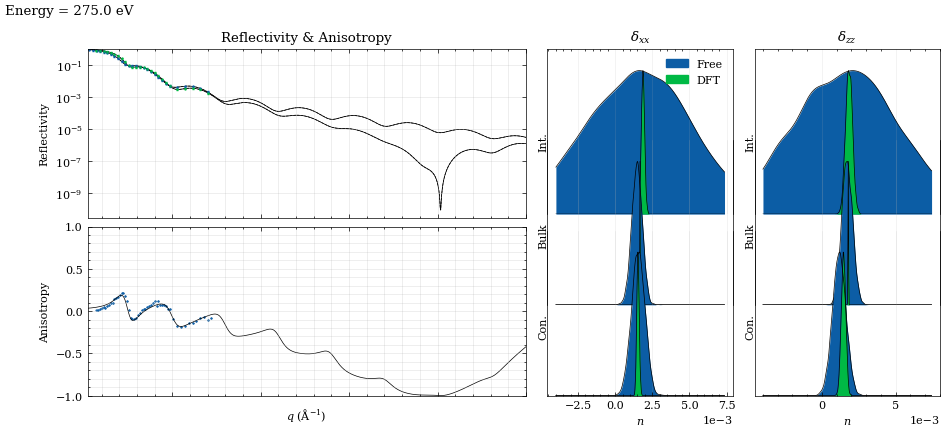

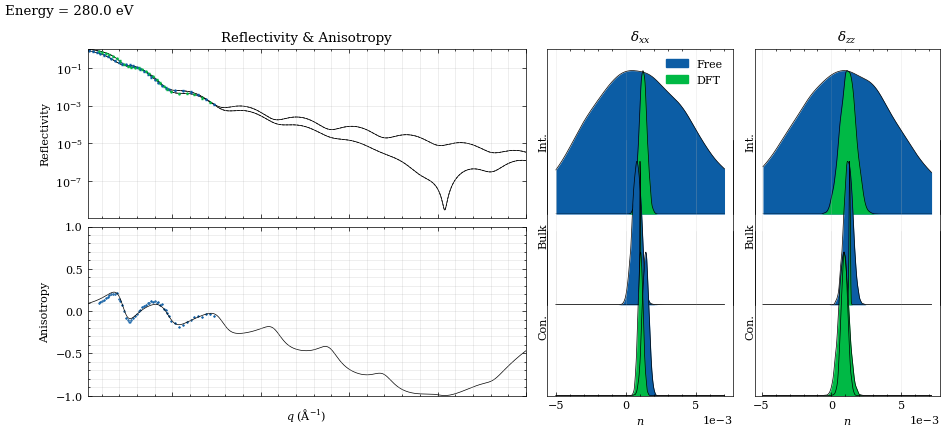

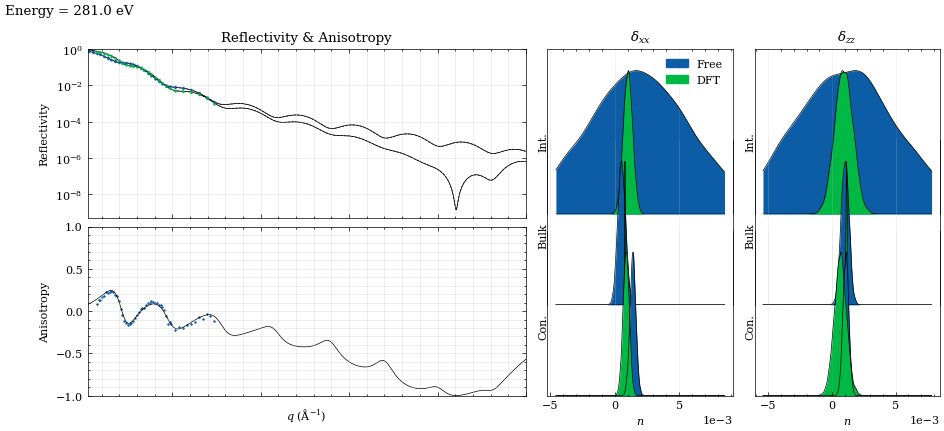

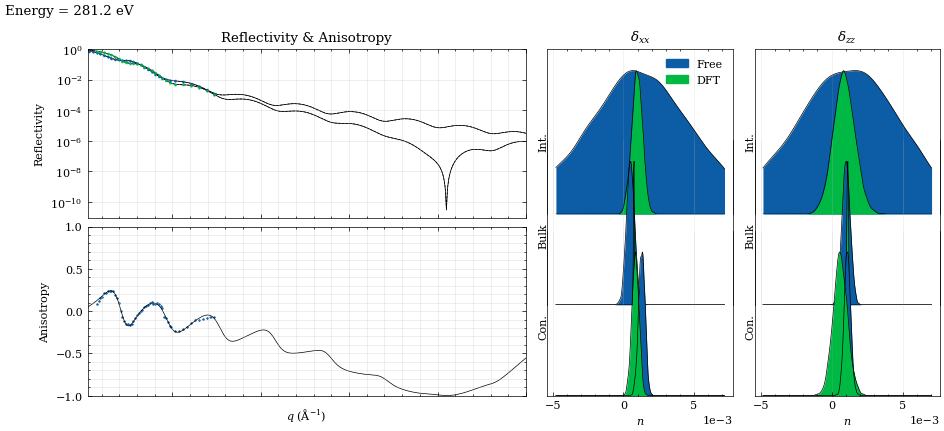

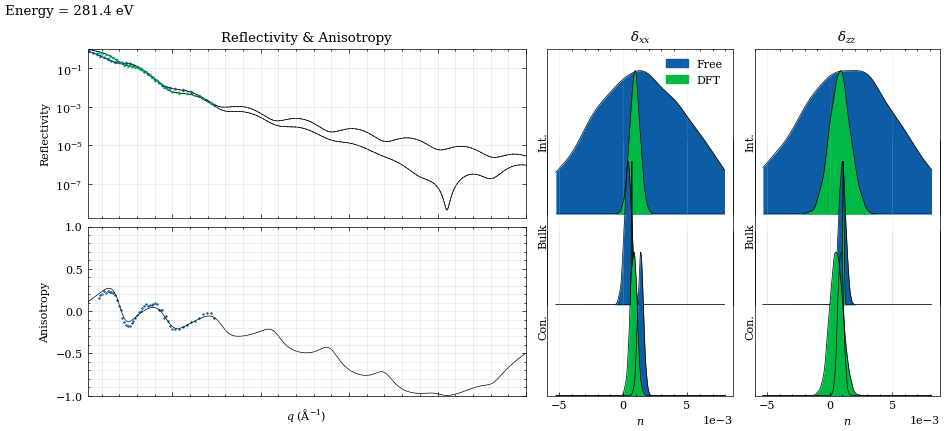

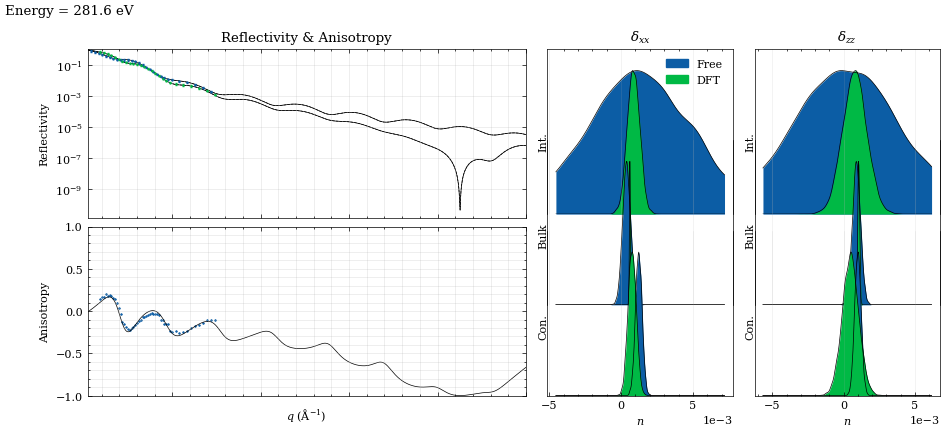

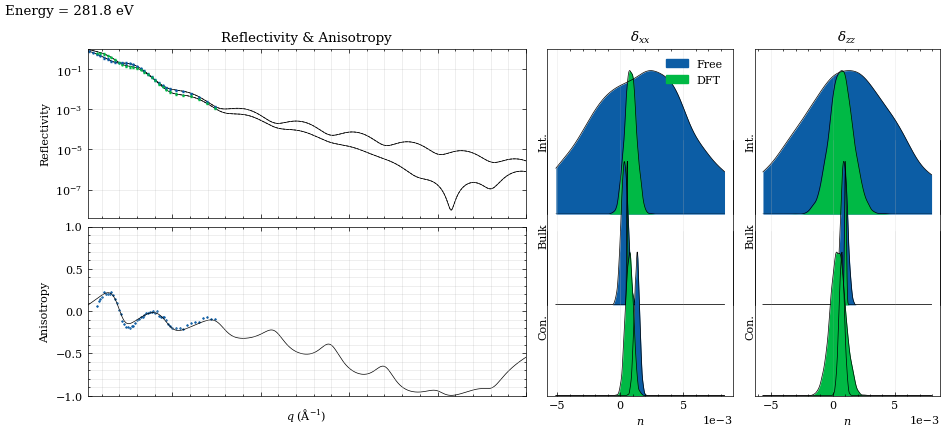

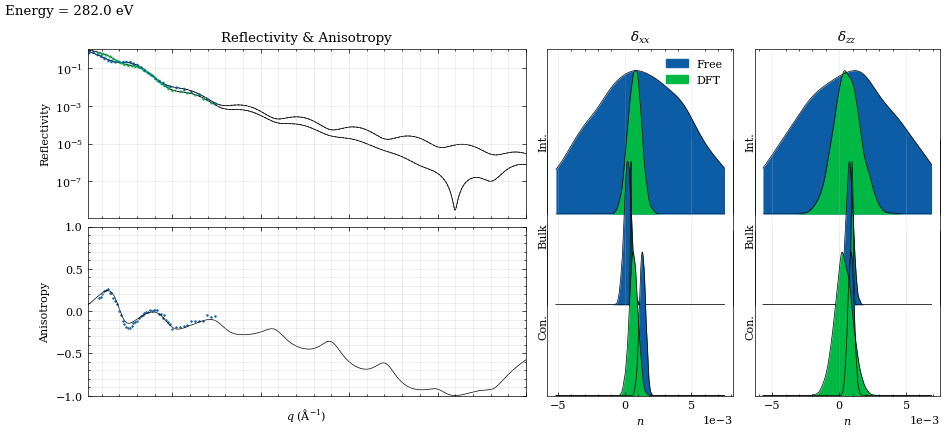

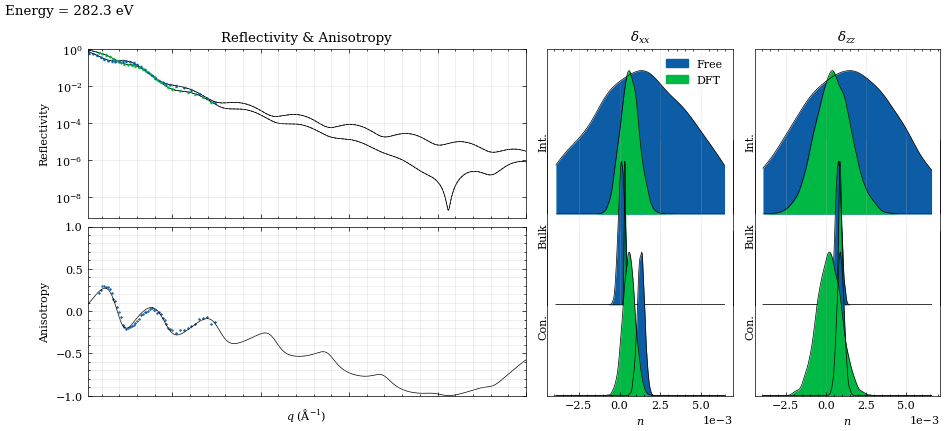

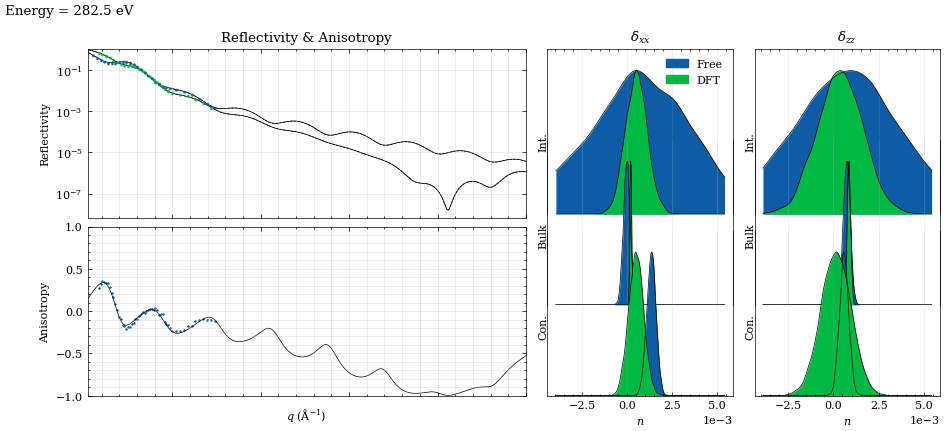

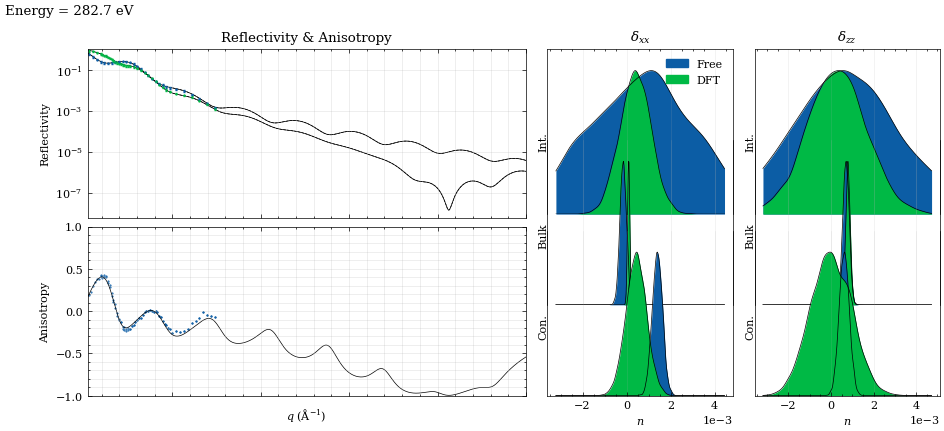

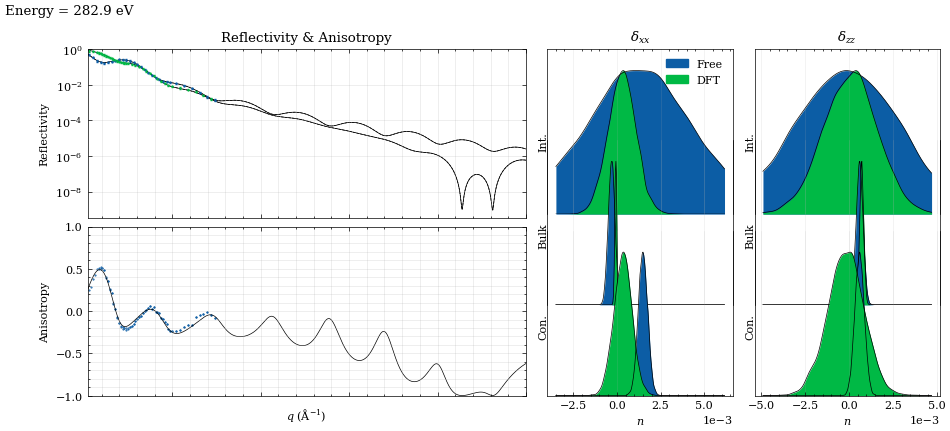

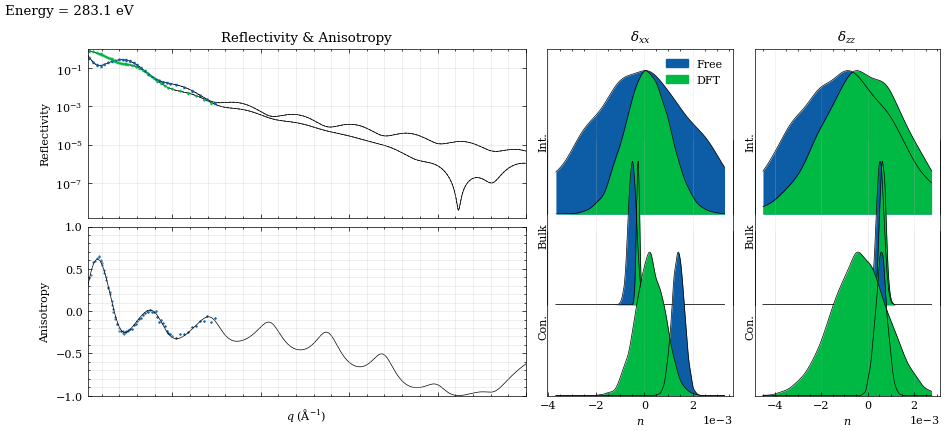

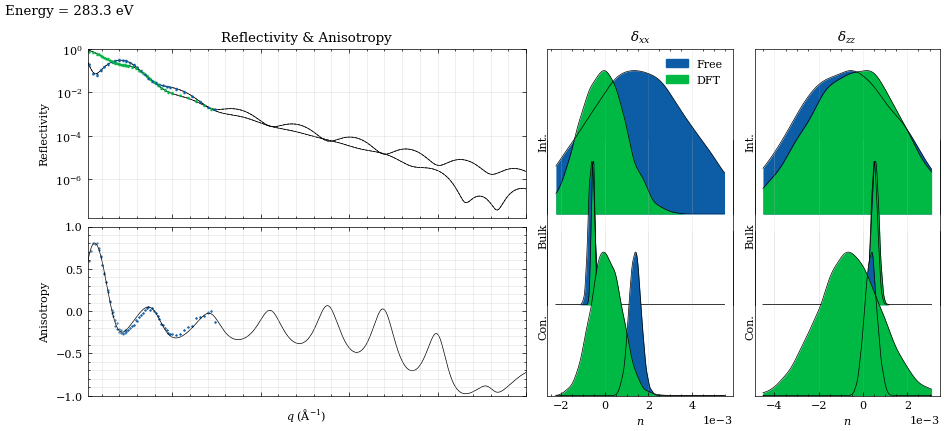

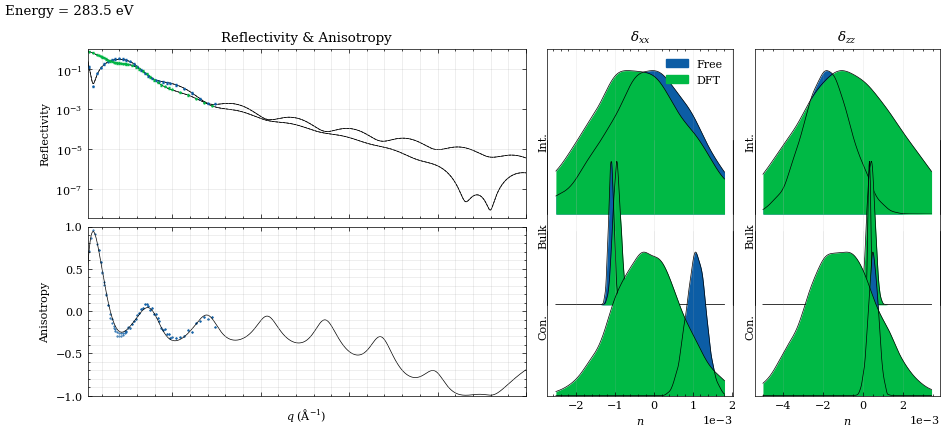

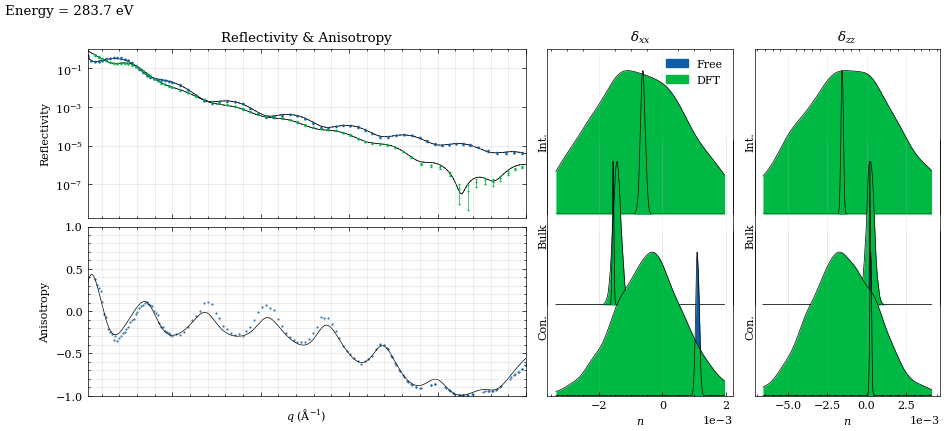

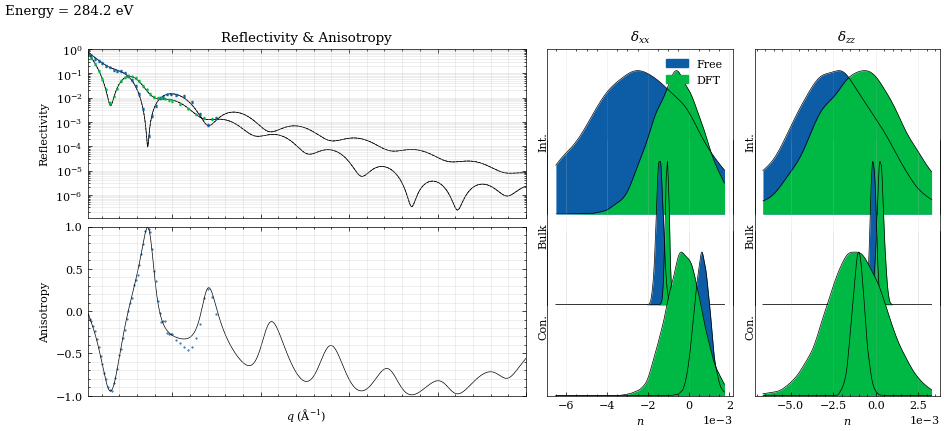

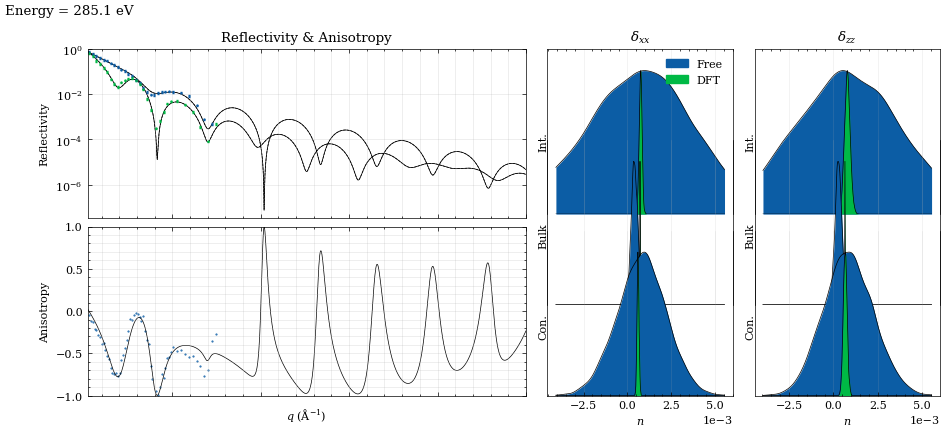

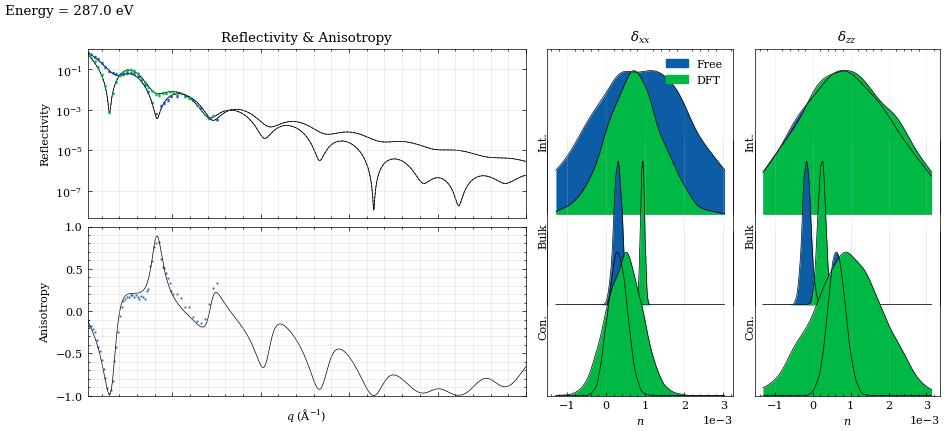

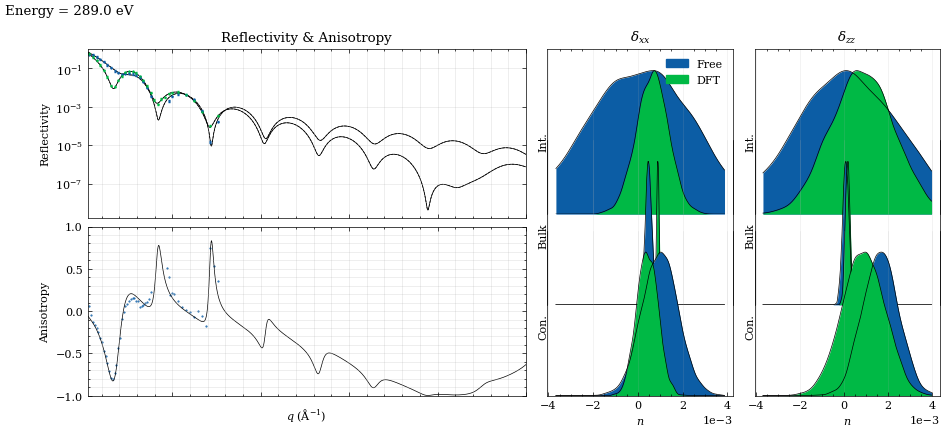

In [20]:
# Sort objectives by energy
objectives.sort(key=lambda o: o.model.energy)

def plot_obj(o):
    energy = o.model.energy
    if energy == 250.0:
        return

    # Gather optical constants for the selected energy
    c_df, b_df, i_df = (
        exp_c.loc[exp_c["energy"] == energy],
        exp_b.loc[exp_b["energy"] == energy],
        exp_i.loc[exp_i["energy"] == energy],
    )
    c_dft, b_dft, i_dft = (
        dft_c.loc[dft_c["energy"] == energy],
        dft_b.loc[dft_b["energy"] == energy],
        dft_i.loc[dft_i["energy"] == energy],
    )
    layer_pairs = [
        ("Int.", i_df, i_dft),
        ("Bulk", b_df, b_dft),
        ("Con.", c_df, c_dft),
    ]

    rng = np.random.default_rng()
    sample_size = 5_000

    def make_samples(component: str) -> pd.DataFrame:
        value_col = f"n_{component}"
        err_col = f"n_{component}_err"
        records: list[pd.DataFrame] = []
        for layer_name, free_df, dft_df in layer_pairs:
            mean_free = float(free_df[value_col].iloc[0])
            err_free = float(free_df[err_col].iloc[0])
            mean_dft = float(dft_df[value_col].iloc[0])
            err_dft = float(dft_df[err_col].iloc[0])
            records.append(
                pd.DataFrame(
                    {
                        "layer": layer_name,
                        "Free": rng.normal(loc=mean_free, scale=err_free, size=sample_size),
                        "DFT": rng.normal(loc=mean_dft, scale=err_dft, size=sample_size),
                    }
                )
            )
        return pd.concat(records, ignore_index=True)

    dist_xx = make_samples("xx")
    dist_zz = make_samples("zz")

    # Build consolidated figure using a shared GridSpec to minimize whitespace
    fig = plt.figure(figsize=(11, 4.5))
    gs = fig.add_gridspec(2, 3, width_ratios=[2.6, 1.1, 1.1], wspace=0.08, hspace=0.05)

    # Left column: reflectivity and anisotropy sharing x-axis
    ax_refl = fig.add_subplot(gs[0, 0])
    ax_ani = fig.add_subplot(gs[1, 0], sharex=ax_refl)
    plot_rxr(ax_refl, o, o.data, o.model.energy)
    plot_anisotropy(ax_ani, o, o.data, o.model.energy)
    ax_ani.set_xlabel(r"$q$ (Å$^{-1}$)")
    ax_refl.set_title(r"Reflectivity & Anisotropy")
    for ax in (ax_refl, ax_ani):
        ax.grid(True, alpha=0.3, which="both")

    # Helper to draw ridge plots using custom KDEs to keep full layout control
    def draw_ridge(subplot_spec, data: pd.DataFrame, title: str):
        layers_order = [layer for layer, *_ in layer_pairs]
        inner = GridSpecFromSubplotSpec(len(layers_order), 1, subplot_spec=subplot_spec, hspace=-0.45)
        axes = []
        x_min = data[["Free", "DFT"]].quantile(0.02).min()
        x_max = data[["Free", "DFT"]].quantile(0.98).max()
        grid = np.linspace(x_min, x_max, 400)

        for idx, layer_name in enumerate(layers_order):
            ax_layer = fig.add_subplot(inner[idx, 0], sharex=axes[0] if axes else None)
            subset = data[data["layer"] == layer_name]
            for label, color in [("Free", "C0"), ("DFT", "C1")]:
                values = subset[label].to_numpy()
                if np.allclose(values, values[0]):
                    density = np.zeros_like(grid)
                    peak_index = np.argmin(np.abs(grid - values[0]))
                    density[peak_index] = 1.0
                else:
                    kde = gaussian_kde(values)
                    density = kde(grid)
                    density /= density.max() if density.max() > 0 else 1.0
                ax_layer.fill_between(grid, 0, density, color=color, linewidth=0)
                ax_layer.plot(grid, density, color="k", linewidth=0.5)
            ax_layer.set_ylim(0, 1.15)
            ax_layer.set_yticks([])
            ax_layer.set_ylabel(layer_name, rotation=90, ha="right", va="center")
            ax_layer.yaxis.set_label_coords(-0.02, 0.5)
            ax_layer.grid(True, axis="x", alpha=0.2)
            ax_layer.tick_params(top=False, labeltop=False)
            ax_layer.set_facecolor("none")
            axes.append(ax_layer)

        for idx, ax_layer in enumerate(axes):
            if idx == 0:
                ax_layer.spines["bottom"].set_visible(False)
                # remove ticks on bottom
                ax_layer.tick_params(bottom=False, labelbottom=False, which="both")
            elif idx == len(axes) - 1:
                ax_layer.spines["top"].set_visible(False)
                ax_layer.tick_params(top=False, labeltop=False, which="both")
            else:
                ax_layer.spines["top"].set_visible(False)
                ax_layer.spines["bottom"].set_visible(False)
                ax_layer.tick_params(top=False, labeltop=False, which="both")
                ax_layer.tick_params(bottom=False, labelbottom=False, which="both")
        axes[0].set_title(title)
        axes[-1].set_xlabel(r"$n$")
        axes[-1].ticklabel_format(style="sci", scilimits=(0, 0))
        return axes

    axes_xx = draw_ridge(gs[:, 1], dist_xx, r"$\delta_{xx}$")
    axes_zz = draw_ridge(gs[:, 2], dist_zz, r"$\delta_{zz}$")

    handles = [
        Patch(color="C0", label="Free"),
        Patch(color="C1", label="DFT"),
    ]
    axes_xx[0].legend(handles=handles, loc="upper right", frameon=False)

    fig.suptitle(f"Energy = {energy:.1f} eV", x=0.05, ha="left")
    plt.show()

for i, o in enumerate(objectives):
    plot_obj(o)

In [21]:
structs = {str(o.model.energy): o.model.structure for o in objectives}
energy = [o.model.energy for o in objectives]

def safely_setp(param, **kwargs):
    if param.constraint is not None:
        param.constraint = None
    param.setp(**kwargs)

def open_structural_parameters(
    structure,
):
    """Open the thickness, roughness, and density constraints for a structure."""
    for i, slab in enumerate(structure):
        if i == 0 :
            continue
        elif i in [len(structure) - 1]:
            safely_setp(slab.sld.density, vary=True)
        elif i in [len(structure) - 2]:
            safely_setp(slab.sld.density, vary=True)
        else:
            safely_setp(slab.sld.density, vary=True)
    return structure

opened_structs = {str(e): open_structural_parameters(s) for e, s in structs.items()}
print(opened_structs["250.0"])

________________________________________________________________________________
Structure: Monolayer_250.0
reverse structure: False
________________________________________________________________________________
Parameters: 'Vacuum_250.0' 
________________________________________________________________________________
Parameters: 'Vacuum_250.0_slab'
<Parameter:'Vacuum_250.0_thick', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_250.0_rough', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_250.0_rho', value=0  (fixed) , bounds=[0.0, 0.0]>
<Parameter:'Vacuum_250.0_energy_offset', value=0          , bounds=[-1.0, 1.0], constraint=<Parameter:'energy_offset', value=0          , bounds=[-1.0, 1.0], constraint=<Parameter:'energy_offset', value=0  (fixed) , bounds=[-0.3, 0.3]>>>
________________________________________________________________________________
Parameters: 'Surface_250.0'
________________________________________________________________________________
Parame

In [22]:
def constrain_structures(structure, constraint):
    for slab, slab_constraint in zip(structure.components, constraint.components):
        slab.thick.setp(vary=None, constraint=slab_constraint.thick)
        slab.rough.setp(vary=None, constraint=slab_constraint.rough)
    return structure

for e, s in opened_structs.items():
    if e == "283.7":
        continue
    constrain_structures(s, opened_structs["283.7"])

In [23]:
import pyref.fitting as fit

def wavelength_from_energy(energy):
    return 12398.42 / energy

# Calculate theta from q (A^-1)
def theta_from_q(q, energy):
    wavelength = wavelength_from_energy(energy)
    return np.rad2deg(np.arcsin(q * wavelength / (4 * np.pi)))

def offset(data, energy):
    minq = np.min(data.x)
    min_theta = max(1, theta_from_q(minq, energy))
    return {"vary": True if min_theta > 0 else False, "bounds": (0, min_theta)}

def new_model(energy, structure, loaded_data: fit.XrayReflectDataset):
    mod =  fit.ReflectModel(
        structure, pol="sp", name="Model " + str(energy), energy=energy, bkg=0, scale_p=1, scale_s=1, theta_offset_p=0, theta_offset_s=0
    )
    #  Check if the data associated with this model has a q value > .1 to add in a background
    if loaded_data.p.x.max() > .1:
        min_point = np.argmin(loaded_data.p.y)
        _brewster_data = (loaded_data.p.y[min_point-3: min_point+3], loaded_data.p.y_err[min_point-3: min_point+3])
        bkg = np.mean(_brewster_data)
        mod.bkg.setp(vary=False, value=bkg)
    mod.theta_offset_p.setp(**offset(loaded_data.s, energy))
    mod.theta_offset_s.setp(**offset(loaded_data.p, energy))
    mod.scale_p.setp(vary=True, bounds=(0.9, 1.1))
    mod.scale_s.setp(vary=True, bounds=(0.9, 1.1))
    return mod

#  Build the models
models = {str(e): new_model(e, opened_structs[str(round(e, 1))], loaded_data[str(e)]) for e in energy}

for e, m in models.items():
    if e == "283.7":
        continue
    m.energy_offset.setp(vary=None, constraint=models["283.7"].energy_offset)

print(models["283.7"].parameters)

________________________________________________________________________________
Parameters:  'Model 283.7' 
________________________________________________________________________________
Parameters: 'instrument parameters'
<Parameter:   'scale_s'   , value=1          , bounds=[0.9, 1.1]>
<Parameter:   'scale_p'   , value=1          , bounds=[0.9, 1.1]>
<Parameter:     'bkg'     , value=8.42808e-08  (fixed) , bounds=[-inf, inf]>
<Parameter:'dq - resolution', value=0  (fixed) , bounds=[-inf, inf]>
<Parameter:  'q_offset'   , value=0  (fixed) , bounds=[-inf, inf]>
<Parameter:'energy_offset', value=0  (fixed) , bounds=[-1.0, 1.0]>
<Parameter:'theta_offset_s', value=0          , bounds=[0.0, 1.2500000160781513]>
<Parameter:'theta_offset_p', value=0          , bounds=[0.0, 1.0]>
________________________________________________________________________________
Parameters: 'Structure - Monolayer_283.7'
________________________________________________________________________________
Parameter

In [24]:
best_ani = 0.5

class LogpExtra:
    """Log Prior Constraint for the fitting of reflectometry data."""

    def __init__(self, objective):
        self.objective = objective

    def __call__(self, model, data):
        """Apply custom log-prior constraint."""
        for i, slab in enumerate(model.structure.components):
            if i ==0 or i == len(model.structure.components) - 1:
                continue
            # If ixx or izz exist as parameters check that they are not negative
            if "ixx" in slab.sld.__dict__ and slab.sld.ixx.value < 0:
                return -np.finfo(np.float64).max
            if "izz" in slab.sld.__dict__ and slab.sld.izz.value < 0:
                return -np.finfo(np.float64).max
            # if slab.thick.value < 2 * np.sqrt(2 * np.pi) * slab.rough.value / 2:
            #     return -np.finfo(np.float64).max
        sio2 = model.structure.components[-2]
        si = model.structure.components[-1]
        if sio2.sld.density.value > si.sld.density.value:
            return -np.finfo(np.float64).max
        return 0

def new_objective(model, data):
    _o= fit.AnisotropyObjective(model, data, logp_anisotropy_weight=.5)
    _o.transform = fit.Transform("logY")
    lpe = LogpExtra(_o)
    _o.logp_extra = lpe
    return _o

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-0.6642111023395499: : 57it [00:30,  1.89it/s]
100%|██████████| 1000/1000 [04:46<00:00,  3.49it/s]
-1.1769122327551877: : 24it [00:18,  1.32it/s]
100%|██████████| 1000/1000 [03:14<00:00,  5.14it/s]


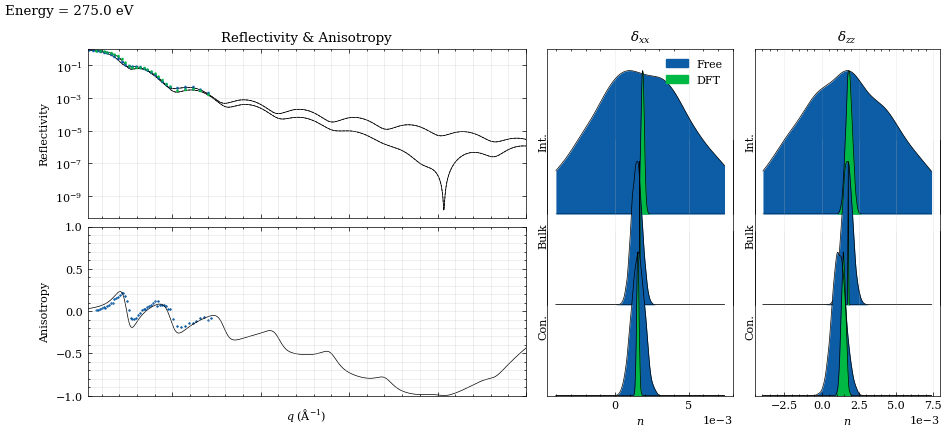

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.1913750035859876: : 33it [00:19,  1.66it/s]
100%|██████████| 1000/1000 [03:03<00:00,  5.46it/s]


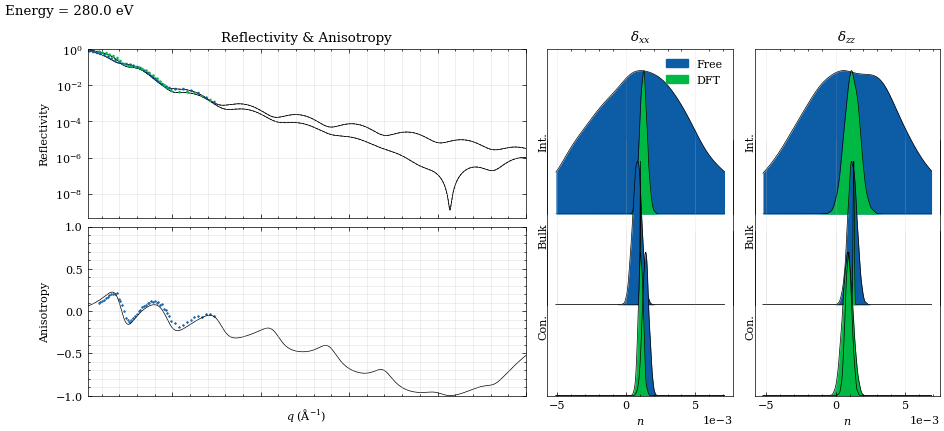

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.1681765232009573: : 35it [00:51,  1.46s/it]
100%|██████████| 1000/1000 [03:04<00:00,  5.41it/s]


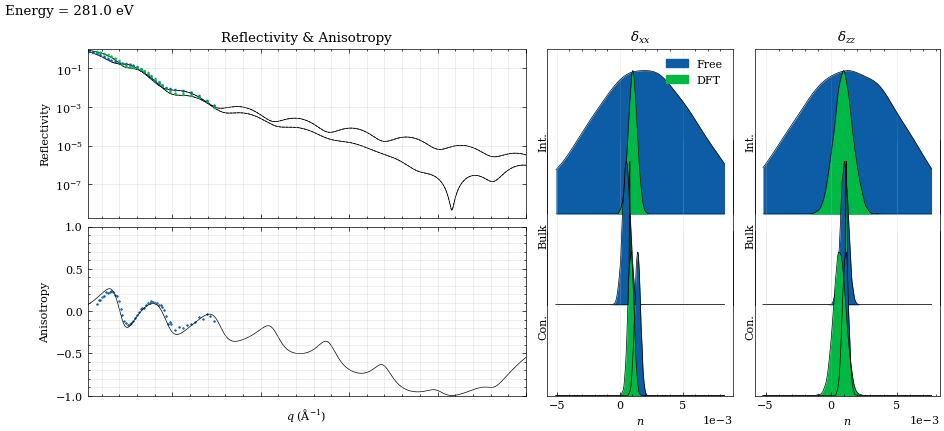

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.1856628071979165: : 38it [00:17,  2.17it/s]
100%|██████████| 1000/1000 [03:04<00:00,  5.43it/s]


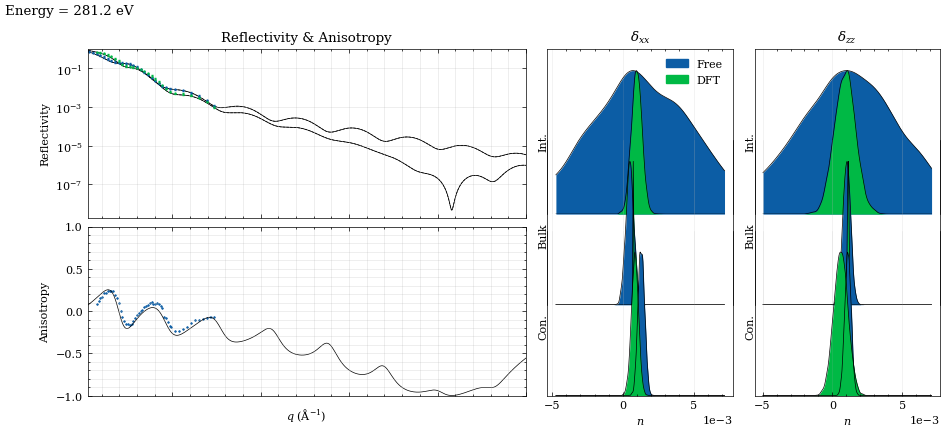

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.1936539948088158: : 27it [00:25,  1.06it/s]
100%|██████████| 1000/1000 [03:05<00:00,  5.38it/s]


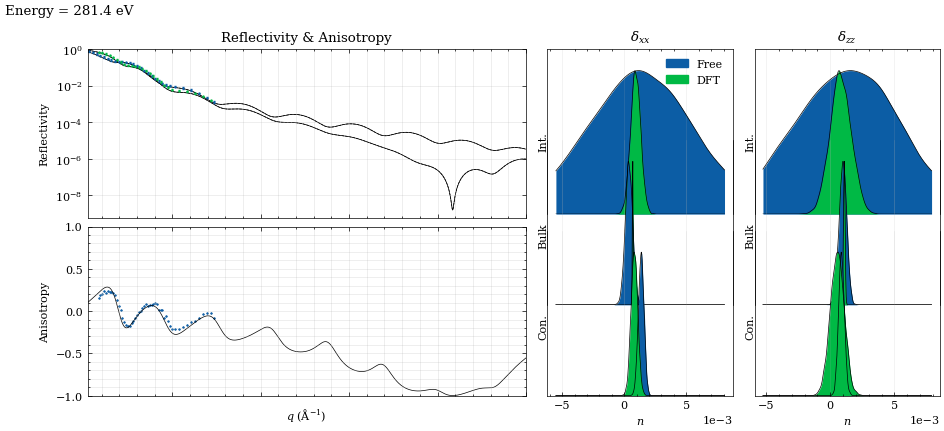

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.1950373869792181: : 35it [01:14,  2.13s/it]
100%|██████████| 1000/1000 [03:08<00:00,  5.30it/s]


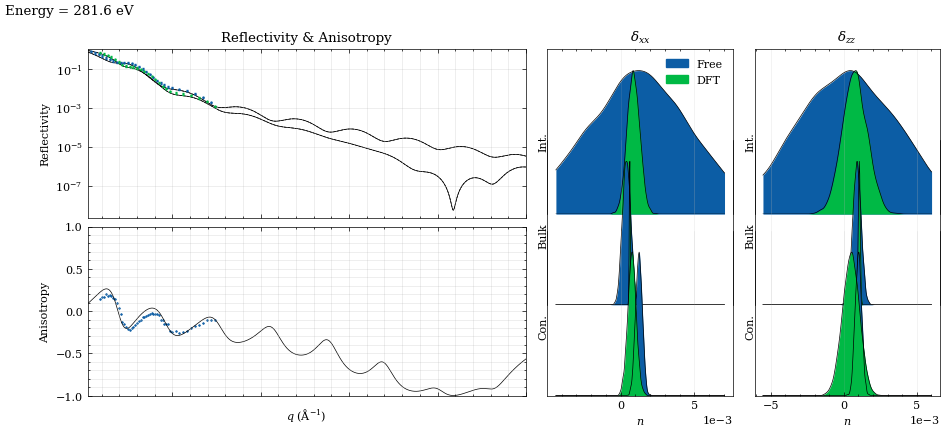

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.1841076412611165: : 42it [01:08,  1.64s/it]
100%|██████████| 1000/1000 [02:32<00:00,  6.57it/s]


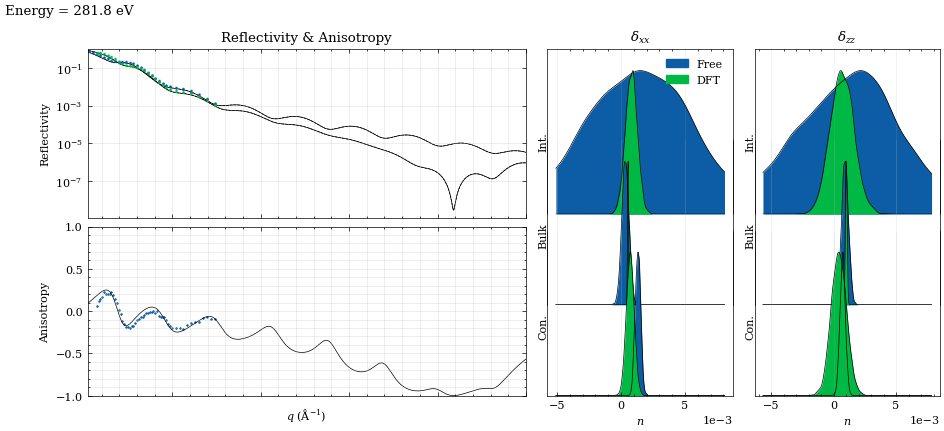

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.182504755640082: : 34it [00:19,  1.70it/s]  
100%|██████████| 1000/1000 [02:24<00:00,  6.92it/s]


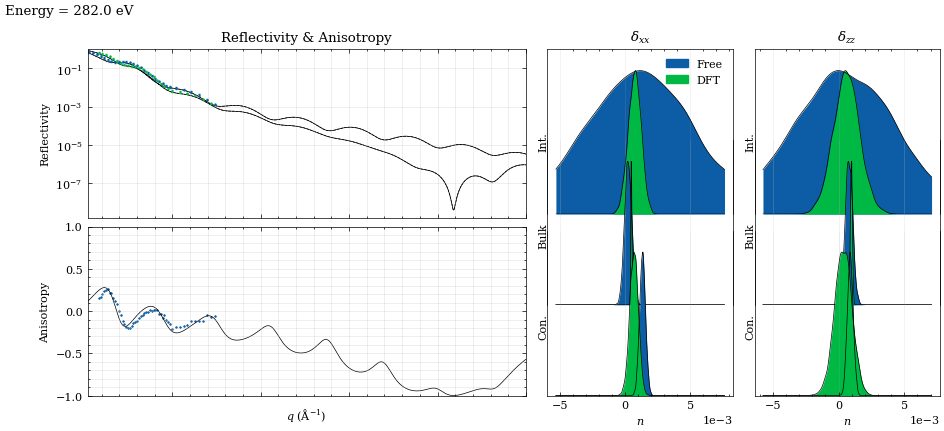

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.1898042558102366: : 52it [00:26,  1.94it/s]
100%|██████████| 1000/1000 [02:22<00:00,  7.04it/s]


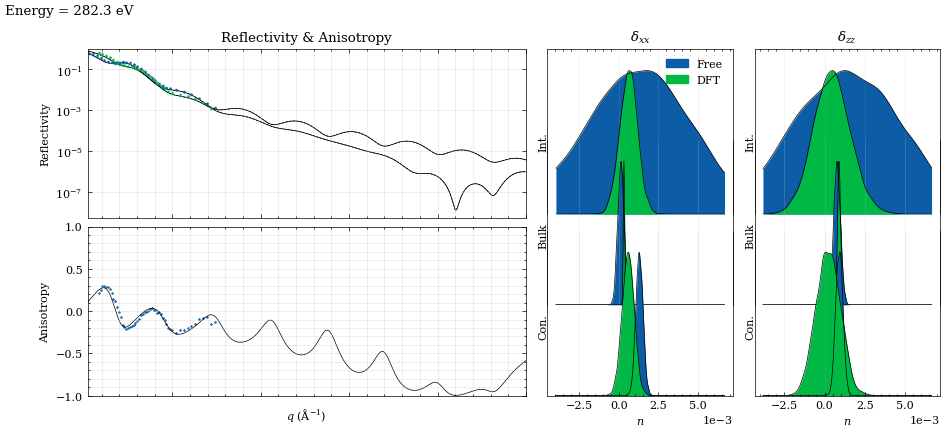

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.1909867794187219: : 48it [02:42,  3.38s/it]
100%|██████████| 1000/1000 [02:25<00:00,  6.89it/s]


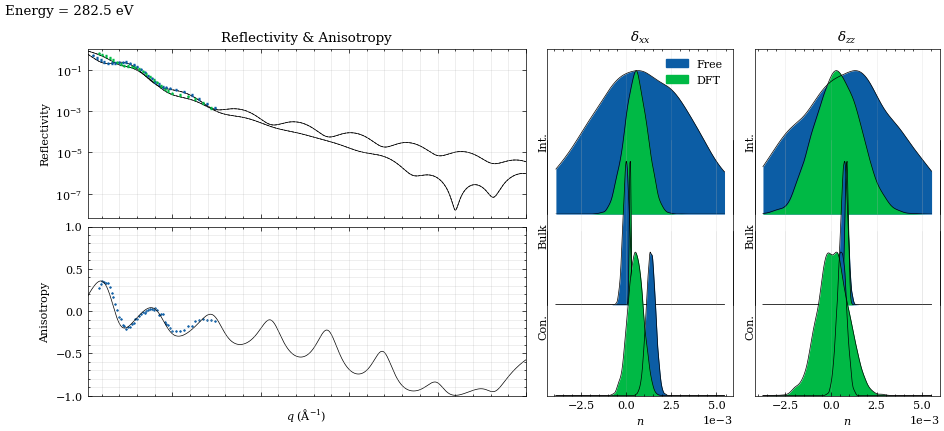

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.172280984738648: : 41it [01:25,  2.08s/it] 
100%|██████████| 1000/1000 [02:30<00:00,  6.64it/s]


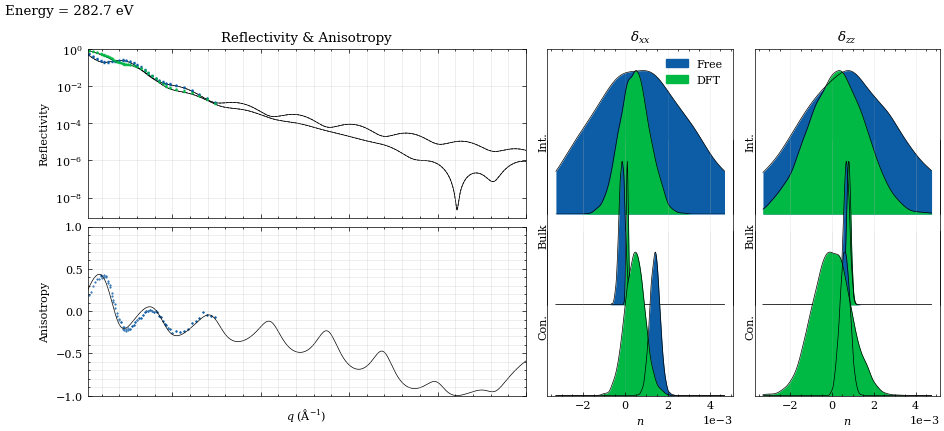

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.1749481248689289: : 48it [00:17,  2.68it/s]
100%|██████████| 1000/1000 [02:26<00:00,  6.83it/s]


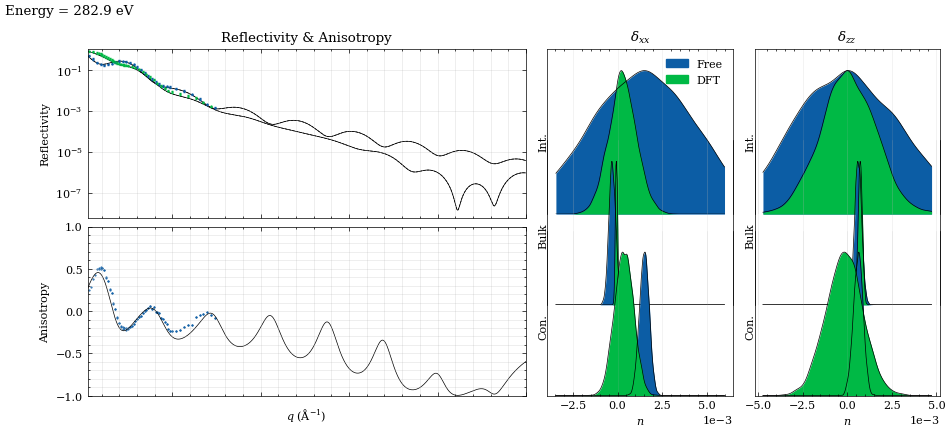

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.170151781855818: : 46it [00:22,  2.03it/s] 
100%|██████████| 1000/1000 [02:29<00:00,  6.67it/s]


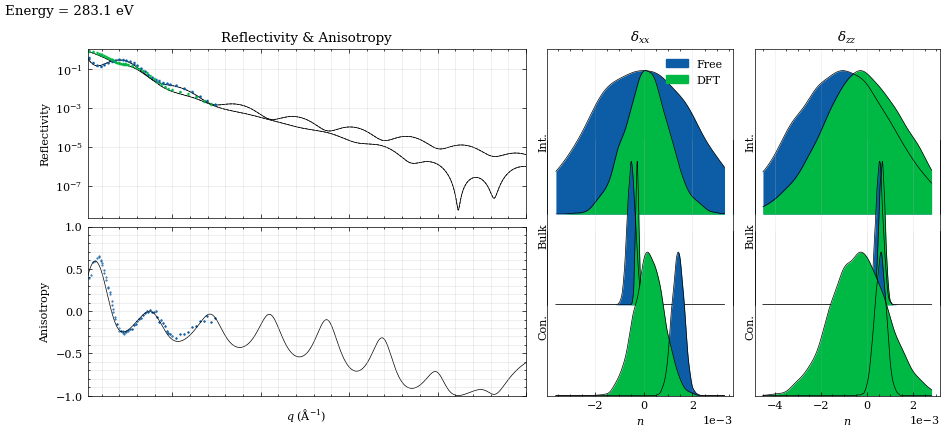

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.1592158249859486: : 78it [00:24,  3.22it/s] 
100%|██████████| 1000/1000 [02:38<00:00,  6.30it/s]


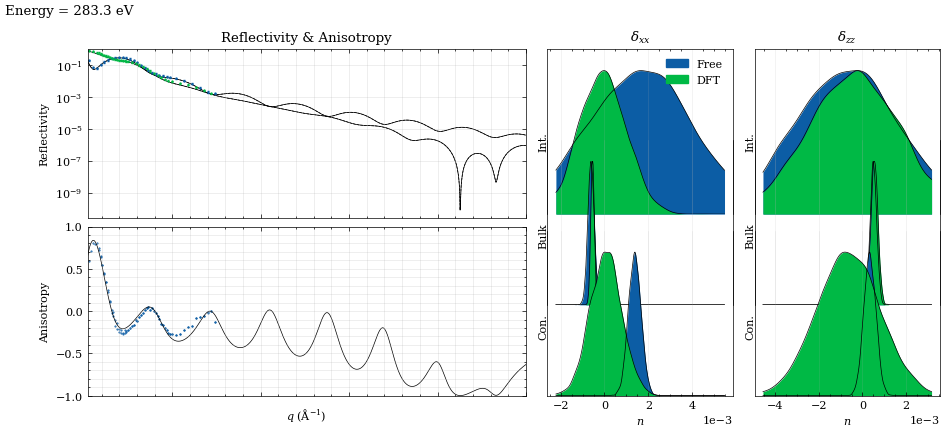

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-1.0190332620832727: : 166it [00:28,  5.89it/s]
100%|██████████| 1000/1000 [02:33<00:00,  6.50it/s]


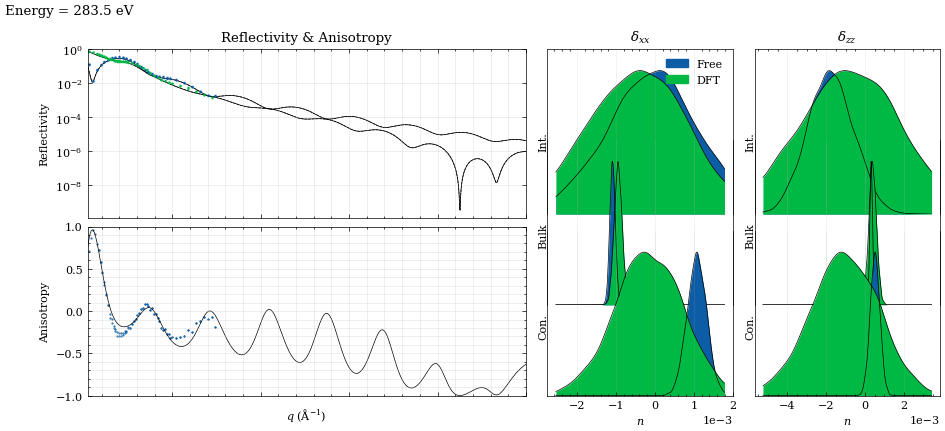

0it [00:00, ?it/s]/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:487: UserWarning: differential_evolution: the 'workers' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,
/home/hduva/projects/xrr_notebooks/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:193: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
-0.8528736822007262: : 138it [00:59,  2.33it/s]
100%|██████████| 1000/1000 [02:36<00:00,  6.37it/s]
-0.16186611344309002: : 890it [02:00,  7.41it/s] 
100%|██████████| 1000/1000 [02:18<00:00,  7.20it/s]
1.7075420172577265: : 304it [00:41,  7.38it/s]
100%|██████████| 1000/1000 [02:18<00:00,  7.20it/s]
2.852738553991595: : 375it [00:49,  7.50it/s] 
100%|██████████| 1000/1000 [02:18<00:00,  7.24it/s]
-0.7877456635915375: : 608it [01:18,  7.78it/s] 
100%|██████████| 1000/1000 [02:15<00:00,  7.35it/s]


In [26]:
from helper import reduced_chi2, bic, aic
import scienceplots

objs = [new_objective(models[str(e)], loaded_data[str(e)]) for e in energy]
fit_objs = []
for o in objs:
    fitter = fit.CurveFitter(o)
    fitter.fit("differential_evolution", workers=CPU_COUNT)
    fitter.sample(1000)
    fit_objs.append(o)
    if o.model.energy < 283.7:
        plot_obj(o)

In [28]:
# Package into a global objective and save
output = fit.GlobalObjective(objs)
# Remove logp_extra from the objectives for saving
for o in output.objectives:
    o.logp_extra = None
with open("fitting_results_free_model_2.pkl", "wb") as f:
    pickle.dump(output, f)
